In [1]:
using LinearAlgebra
using Random
using Distributions
using KernelDensity
using PyCall
using ForwardDiff
# include("../Inversion/AffineInvariantMCMC.jl")
include("../Inversion/Plot.jl")
include("../Inversion/GaussianMixture.jl")
include("../Inversion/GMBBVI.jl")
include("../Inversion/AnnealingInitialize.jl")
include("./MultiModal.jl")

Gaussian_mixture_VI (generic function with 1 method)

## 1. Gaussian Likelihood Function

Consider the following inverse problem:
$$
\begin{align*}
y &= A \theta + \eta, \quad A = \begin{bmatrix} 1.0 & 1.0 \\ 1.0 & 2.0 \end{bmatrix} \\
y &= \begin{bmatrix} 0.0 \\ 1.0 \end{bmatrix}, \quad \Sigma_{\eta} = I
\end{align*}
$$
We assume a noninformative uniform prior. The target is to sample the posterior $p(\theta|y) \propto \exp\left(-\frac{1}{2} F(\theta)^T F(\theta)\right)$, where the residual function is:
$$ F(\theta) = y - A\theta $$

## 2. Four-Mode Likelihood Function

Consider the following inverse problem:
$$
\begin{align*}
y &= \begin{bmatrix} 4.2297 \\ 4.2297 \\ 0.5 \\ 0.0 \end{bmatrix}, \quad 
G(\theta) = \begin{bmatrix} (\theta_{(1)} - \theta_{(2)})^2 \\ (\theta_{(1)} + \theta_{(2)})^2 \\ \theta_{(1)} \\ \theta_{(2)} \end{bmatrix}
\end{align*}
$$
We sample the posterior $p(\theta|y) \propto \exp\left(-\frac{1}{2} F(\theta)^T F(\theta)\right)$, where the residual function is defined by:
$$ F(\theta) = y - G(\theta) $$

## 3. Circle Shape Likelihood Function

Consider the following inverse problem:
$$
\begin{align*}
y &= \theta^T A \theta + \eta, \quad A = I \\
y &= 1.0, \quad \Sigma_{\eta} = \sigma_\eta^2 = 0.3^2
\end{align*}
$$
This results in a ring-shaped posterior distribution. We sample $p(\theta|y) \propto \exp\left(-\frac{1}{2} F(\theta)^T F(\theta)\right)$, where:
$$ F(\theta) = \frac{y - \|\theta\|^2}{\sigma_\eta} $$

## 4. Banana Shape Likelihood Function

Consider the following inverse problem:
$$
\begin{align*}
y &= \begin{bmatrix} \lambda(\theta_{(2)} - \theta_{(1)}^2) \\ \theta_{(1)} \end{bmatrix} + \eta, \quad \lambda = 10.0 \\
y &= \begin{bmatrix} 0.0 \\ 1.0 \end{bmatrix}, \quad \Sigma_{\eta} = \sigma_\eta^2 I = (\sqrt{10})^2 I
\end{align*}
$$
The target is to sample $p(\theta|y) \propto \exp\left(-\frac{1}{2} F(\theta)^T F(\theta)\right)$, where the residual function is:
$$ F(\theta) = \begin{bmatrix} \frac{y_{(1)} - \lambda(\theta_{(2)} - \theta_{(1)}^2)}{\sigma_\eta} \\ \frac{y_{(2)} - \theta_{(1)}}{\sigma_\eta} \end{bmatrix} $$

## 5. Funnel Shape Likelihood Function

Consider the following inverse problem:

$$
\begin{align*}
\theta_{(1)} &\sim \mathcal{N}(0, 3^2) \\
\theta_{(i)} | \theta_{(1)} &\sim \mathcal{N}(0, \exp(\theta_{(1)})), \quad i = 2, \dots, d
\end{align*}
$$

The potential function $\Phi(\theta)$ for a 2D case ($N_x=2$) is:
$$ \Phi(\theta) = \frac{\theta_{(1)}^2}{2 \cdot 3^2} + \frac{\theta_{(2)}^2}{2 \exp(\theta_{(1)})} + \frac{1}{2}\theta_{(1)} $$

In [2]:
function auto_add_python_path(target_file="WALNUTS.py")
    py_sys = pyimport("sys")
    curr = pwd() 
    
    for i in 1:4
        for (root, dirs, files) in walkdir(curr)
            if target_file in files
                if !(root in py_sys.path)
                    pushfirst!(PyVector(py_sys."path"), root)
                    @info "Found and added Python path: $root"
                    return true
                end
            end
        end
        curr = dirname(curr) 
    end
    @warn "Could not find $target_file automatically."
    return false
end

auto_add_python_path("WALNUTS.py")
const wn = pyimport("WALNUTS")
const ai = pyimport("adaptiveIntegrators")
const emcee = pyimport("emcee")

function run_walnuts_python(target_phi_julia, q0, n_x, n_iter)
    function target_func_py(q)
        val = -target_phi_julia(q)
        grad = -ForwardDiff.gradient(target_phi_julia, q)
        return (val, grad) 
    end

    samples_w, diag_w = wn.WALNUTS(
        target_func_py, q0, 
        generated = (q -> q),
        integrator = ai.adaptLeapFrogR2P,
        M=12, H0=0.3, delta0=0.3, numIter=1000, warmupIter=1000,
        adaptDeltaTarget=0.6, recordOrbitStats=false
    )

    q_curr = samples_w[:, end]
    H_curr = diag_w[end, 16]    
    delta_curr = diag_w[end, 19] 

    samples, _, _, _ = wn.WALNUTS(
        target_func_py, q_curr,
        generated = (q -> q),
        integrator = ai.adaptLeapFrogR2P,
        M=12, H0=H_curr, delta0=delta_curr,
        numIter=n_iter, warmupIter=0,
        recordOrbitStats=true
    )

    return samples 
end

function run_emcee_python(target_phi_julia, ens_0, n_iter)
    ndim, nwalkers = size(ens_0)
    lp_py(q) = -target_phi_julia(q)
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lp_py)
    
    sampler.run_mcmc(ens_0', n_iter + 1, progress=false)
    
    chain = sampler.get_chain() 
    
    res = permutedims(chain, (3, 2, 1))
    return res
end

function calculate_gm_stats(weights, means, covs)
    w = weights / sum(weights)
    N_modes, N_θ = size(means)

    total_mean = zeros(N_θ)
    for i in 1:N_modes
        total_mean += w[i] * means[i, :]
    end

    e_cov = zeros(N_θ, N_θ)
    cov_e = zeros(N_θ, N_θ)
    for i in 1:N_modes
        e_cov += w[i] * covs[i, :, :]
        cov_e += w[i] * (means[i, :] * means[i, :]')
    end
    total_cov = e_cov + cov_e - (total_mean * total_mean')
    
    return total_mean, total_cov
end

function calculate_sample_stats(samples)
    if isempty(samples) || size(samples, 2) < 2
        return fill(NaN, size(samples, 1)), fill(NaN, size(samples, 1), size(samples, 1))
    end
    total_mean = mean(samples, dims=2)[:, 1]
    total_cov = cov(samples') 
    return total_mean, total_cov
end

function visualization(ax, obj_GMBBVI, ens_MCMC, ens_WALNUTS; Nx = 200, Ny = 200, x_lim=[-3.0, 3.0], y_lim=[-3.0, 3.0],
        func_F = nothing, func_Phi = nothing, bandwidth=nothing, make_label::Bool=false, N_iter=500, Num=5000)

        x_min, x_max = x_lim
        y_min, y_max = y_lim

        xx = LinRange(x_min, x_max, Nx)
        yy = LinRange(y_min, y_max, Ny)
        dx, dy = xx[2] - xx[1], yy[2] - yy[1]
        X,Y = repeat(xx, 1, Ny), repeat(yy, 1, Nx)'

        Z_ref = (func_Phi === nothing ? posterior_2d(func_F, X, Y, "func_F") : posterior_2d(func_Phi, X, Y, "func_Phi"))
        color_lim = (minimum(Z_ref), maximum(Z_ref))
        ax[1].pcolormesh(X, Y, Z_ref, cmap="viridis", clim=color_lim)

        error = zeros(3, N_iter+1)

        if obj_GMBBVI !=nothing
                for iter = 0:N_iter
                x_w = exp.(obj_GMBBVI.logx_w[iter+1]); x_w /= sum(x_w)
                x_mean = obj_GMBBVI.x_mean[iter+1][:,1:2]
                xx_cov = obj_GMBBVI.xx_cov[iter+1][:,1:2,1:2]
                Z = Gaussian_mixture_2d(x_w, x_mean, xx_cov,  X, Y)
                error[1, iter+1] = norm(Z - Z_ref,1)*dx*dy
                
                if iter == N_iter
                        ax[2].pcolormesh(X, Y, Z, cmap="viridis", clim=color_lim)
                        ax[2].scatter([obj_GMBBVI.x_mean[1][:,1];], [obj_GMBBVI.x_mean[1][:,2];], marker="x", color="grey", alpha=0.5) 
                        ax[2].scatter([x_mean[:,1];], [x_mean[:,2];], marker="o", color="red", facecolors="none", alpha=0.5)

                        mean_val, cov_val = calculate_gm_stats(x_w, x_mean, xx_cov)
                        text_str = "μ:[$(round(mean_val[1], digits=2)), $(round(mean_val[2], digits=2))]\\nσ²: [$(round(cov_val[1,1], digits=2)), $(round(cov_val[2,2], digits=2))]"
                        ax[2].text(0.05, 0.95, text_str, transform=ax[2].transAxes, fontsize=8,
                                   verticalalignment="top", bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "alpha"=>0.7))
                end
                end
        end

        if ens_MCMC!=nothing
                boundary=((x_lim[1],x_lim[2]),(y_lim[1],y_lim[2]))
                for iter = 0:N_iter
                
                samples_iter_2d = ens_MCMC[1:2, :, iter+1]
                
                if bandwidth==nothing
                        kde_iter=kde(samples_iter_2d';boundary=boundary,npoints=(Nx,Ny))
                else
                        kde_iter=kde(samples_iter_2d';boundary=boundary,npoints=(Nx,Ny),bandwidth=bandwidth)
                end

                Z = kde_iter.density
                sum_Z = sum(Z)
                if sum_Z > 0 Z ./= (sum_Z*dx*dy) end
                error[2, iter+1] = norm(Z - Z_ref,1)*dx*dy
                
                if iter == N_iter
                        last_n_iters=10
                        last_ens=hcat([ens_MCMC[1:2, :, i] for i in N_iter+2-last_n_iters:N_iter+1]...)
                        last_ens_number=size(last_ens,2)

                        if bandwidth==nothing
                        kde_last=kde(last_ens'; boundary=boundary, npoints=(Nx,Ny))
                        else
                        kde_last=kde(last_ens'; boundary=boundary, npoints=(Nx,Ny), bandwidth=bandwidth)
                        end

                        Z = kde_last.density
                        sum_Z = sum(Z)
                        if sum_Z > 0 Z ./= (sum_Z*dx*dy) end

                        ax[3].pcolormesh(X, Y, Z, cmap="viridis", clim=color_lim)
                        ax[3].scatter(last_ens[1,:], last_ens[2,:], marker=".", color="red", s=10, alpha=100/last_ens_number)
                        ax[3].set_xlim(x_lim)
                        ax[3].set_ylim(y_lim)
                        
                        mean_val, cov_val = calculate_sample_stats(last_ens)
                        if !any(isnan, mean_val)
                            text_str = "μ:[$(round(mean_val[1], digits=2)), $(round(mean_val[2], digits=2))]\\nσ²: [$(round(cov_val[1,1], digits=2)), $(round(cov_val[2,2], digits=2))]"
                            ax[3].text(0.05, 0.95, text_str, transform=ax[3].transAxes, fontsize=8,
                                       verticalalignment="top", bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "alpha"=>0.7))
                        end
                        end
                end
        end
        
        # WALNUTS Error Calculation
        if ens_WALNUTS!=nothing
                boundary=((x_lim[1],x_lim[2]),(y_lim[1],y_lim[2]))
                samples_per_iter = div(Num, N_iter)
                total_samples = size(ens_WALNUTS, 2)
                for iter = 0:N_iter
                        n_samples_end = min((iter + 1) * samples_per_iter, total_samples)
                        if n_samples_end < 2
                                error[3, iter+1] = NaN
                                continue
                        end
                        
                        samples_iter_2d = ens_WALNUTS[1:2, 1:n_samples_end]

                        if bandwidth==nothing
                                kde_iter=kde(samples_iter_2d';boundary=boundary,npoints=(Nx,Ny))
                        else
                                kde_iter=kde(samples_iter_2d';boundary=boundary,npoints=(Nx,Ny),bandwidth=bandwidth)
                        end
        
                        Z = kde_iter.density
                        sum_Z = sum(Z)
                        if sum_Z > 0 Z ./= (sum_Z*dx*dy) end
                        error[3, iter+1] = norm(Z - Z_ref,1)*dx*dy
                end
        end
    
        # Helper for plotting final MCMC-type distributions
        function plot_mcmc_on_ax(ax_plt, samples, title)
            if samples === nothing || size(samples, 2) < 20
                ax_plt.text(0.5, 0.5, "No Samples", ha="center", va="center")
                ax_plt.set_title(title)
                ax_plt.set_xlim(x_lim)
                ax_plt.set_ylim(y_lim)
                return
            end
        
            ax_plt.set_title(title)
        
            burn_in = div(size(samples, 2), 2)
            
            samples_to_plot = samples[1:2, burn_in+1:end]
        
            if size(samples_to_plot, 2) < 2
                ax_plt.text(0.5, 0.5, "No Samples Post Burn-in", ha="center", va="center")
                return
            end

            kde_boundary = ((x_lim[1], x_lim[2]), (y_lim[1], y_lim[2]))
        
            kde_res = kde(samples_to_plot', boundary=kde_boundary, npoints=(Nx, Ny), bandwidth=bandwidth)
            Z_kde = kde_res.density
            if sum(Z_kde) > 0 Z_kde ./= sum(Z_kde) * dx * dy end
            ax_plt.pcolormesh(X, Y, Z_kde, cmap="viridis", vmin=color_lim[1], vmax=color_lim[2])
        
            alpha_val = min(1.0, 100 / size(samples_to_plot, 2))
            ax_plt.scatter(samples_to_plot[1, :], samples_to_plot[2, :], 
                           marker=".", color="red", s=10, alpha=alpha_val)

            mean_val, cov_val = calculate_sample_stats(samples_to_plot)
            
            if !any(isnan, mean_val) && !any(isnan, cov_val)
                text_str = "μ: [$(round(mean_val[1], digits=2)), $(round(mean_val[2], digits=2))]\\nσ²: [$(round(cov_val[1,1], digits=2)), $(round(cov_val[2,2], digits=2))]"
                ax_plt.text(0.05, 0.95, text_str, transform=ax_plt.transAxes, fontsize=8,
                           verticalalignment="top", bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "alpha"=>0.7))
            end
        
            ax_plt.set_xlim(x_lim)
            ax_plt.set_ylim(y_lim)
        end

    plot_mcmc_on_ax(ax[4], ens_WALNUTS, "WALNUTS")

    ax[5].semilogy(Array(0:N_iter), error', label=["GMBBVI","MCMC","WALNUTS"])   

    if make_label==true
            ax[5].legend()
    end

    ymin, ymax = ax[5].get_ylim()
    if ymin > 0.1
            ax[5].set_ylim(0.1, ymax)
    end
end

[ Info: Found and added Python path: c:\Users\Serein\Desktop\work\InverseProblems.jl\Baselines\WALNUTS


visualization (generic function with 1 method)

# Test the aforementioned examples with different methods

[ Info: Running: Gaussian
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)


iteration #  1000  H =  0.4596123824084303  delta =  0.5192929563948903
iteration #  1000  H =  0.4596123824084303  delta =  0.5192929563948903
iteration #  2000  H =  0.4596123824084303  delta =  0.5192929563948903
iteration #  3000  H =  0.4596123824084303  delta =  0.5192929563948903
iteration #  4000  H =  0.4596123824084303  delta =  0.5192929563948903
iteration #  5000  H =  0.4596123824084303  delta =  0.5192929563948903


[ Info: ("iter = ", 500, " / ", 500)
[ Info: Gaussian - Time: GMBBVI: 0.8293647s, MCMC: 12.7788001s, WALNUTS: 7.5068371s
[ Info: Running: Four mode
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)


iteration #  1000  H =  0.1966084319783878  delta =  0.7001851672729458
iteration #  1000  H =  0.1966084319783878  delta =  0.7001851672729458
iteration #  2000  H =  0.1966084319783878  delta =  0.7001851672729458
iteration #  3000  H =  0.1966084319783878  delta =  0.7001851672729458
iteration #  4000  H =  0.1966084319783878  delta =  0.7001851672729458
iteration #  5000  H =  0.1966084319783878  delta =  0.7001851672729458


[ Info: ("iter = ", 500, " / ", 500)
[ Info: Four_modes - Time: GMBBVI: 1.3951238s, MCMC: 28.4414711s, WALNUTS: 7.5532872s
[ Info: Running: Circle
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)


...

[ Info: ("iter = ", 500, " / ", 500)
[ Info: Circle - Time: GMBBVI: 1.0212066s, MCMC: 22.5773199s, WALNUTS: 32.5585122s
[ Info: Running: Banana
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)


iteration #  1000  H =  0.04080096444565378  delta =  0.14067533435708918
iteration #  1000  H =  0.04080096444565378  delta =  0.14067533435708918
iteration #  2000  H =  0.04080096444565378  delta =  0.14067533435708918
iteration #  3000  H =  0.04080096444565378  delta =  0.14067533435708918
iteration #  4000  H =  0.04080096444565378  delta =  0.14067533435708918
iteration #  5000  H =  0.04080096444565378  delta =  0.14067533435708918


[ Info: ("iter = ", 500, " / ", 500)
[ Info: Banana - Time: GMBBVI: 1.5080498s, MCMC: 21.6267701s, WALNUTS: 95.1901056s
[ Info: Running: Funnel
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)


iteration #  1000  H =  0.5887065292421281  delta =  0.5827410162323312
iteration #  1000  H =  0.5887065292421281  delta =  0.5827410162323312
iteration #  2000  H =  0.5887065292421281  delta =  0.5827410162323312
iteration #  3000  H =  0.5887065292421281  delta =  0.5827410162323312
iteration #  4000  H =  0.5887065292421281  delta =  0.5827410162323312
iteration #  5000  H =  0.5887065292421281  delta =  0.5827410162323312


[ Info: ("iter = ", 500, " / ", 500)
[ Info: Funnel - Time: GMBBVI: 0.7231236s, MCMC: 12.7320145s, WALNUTS: 10.088821s


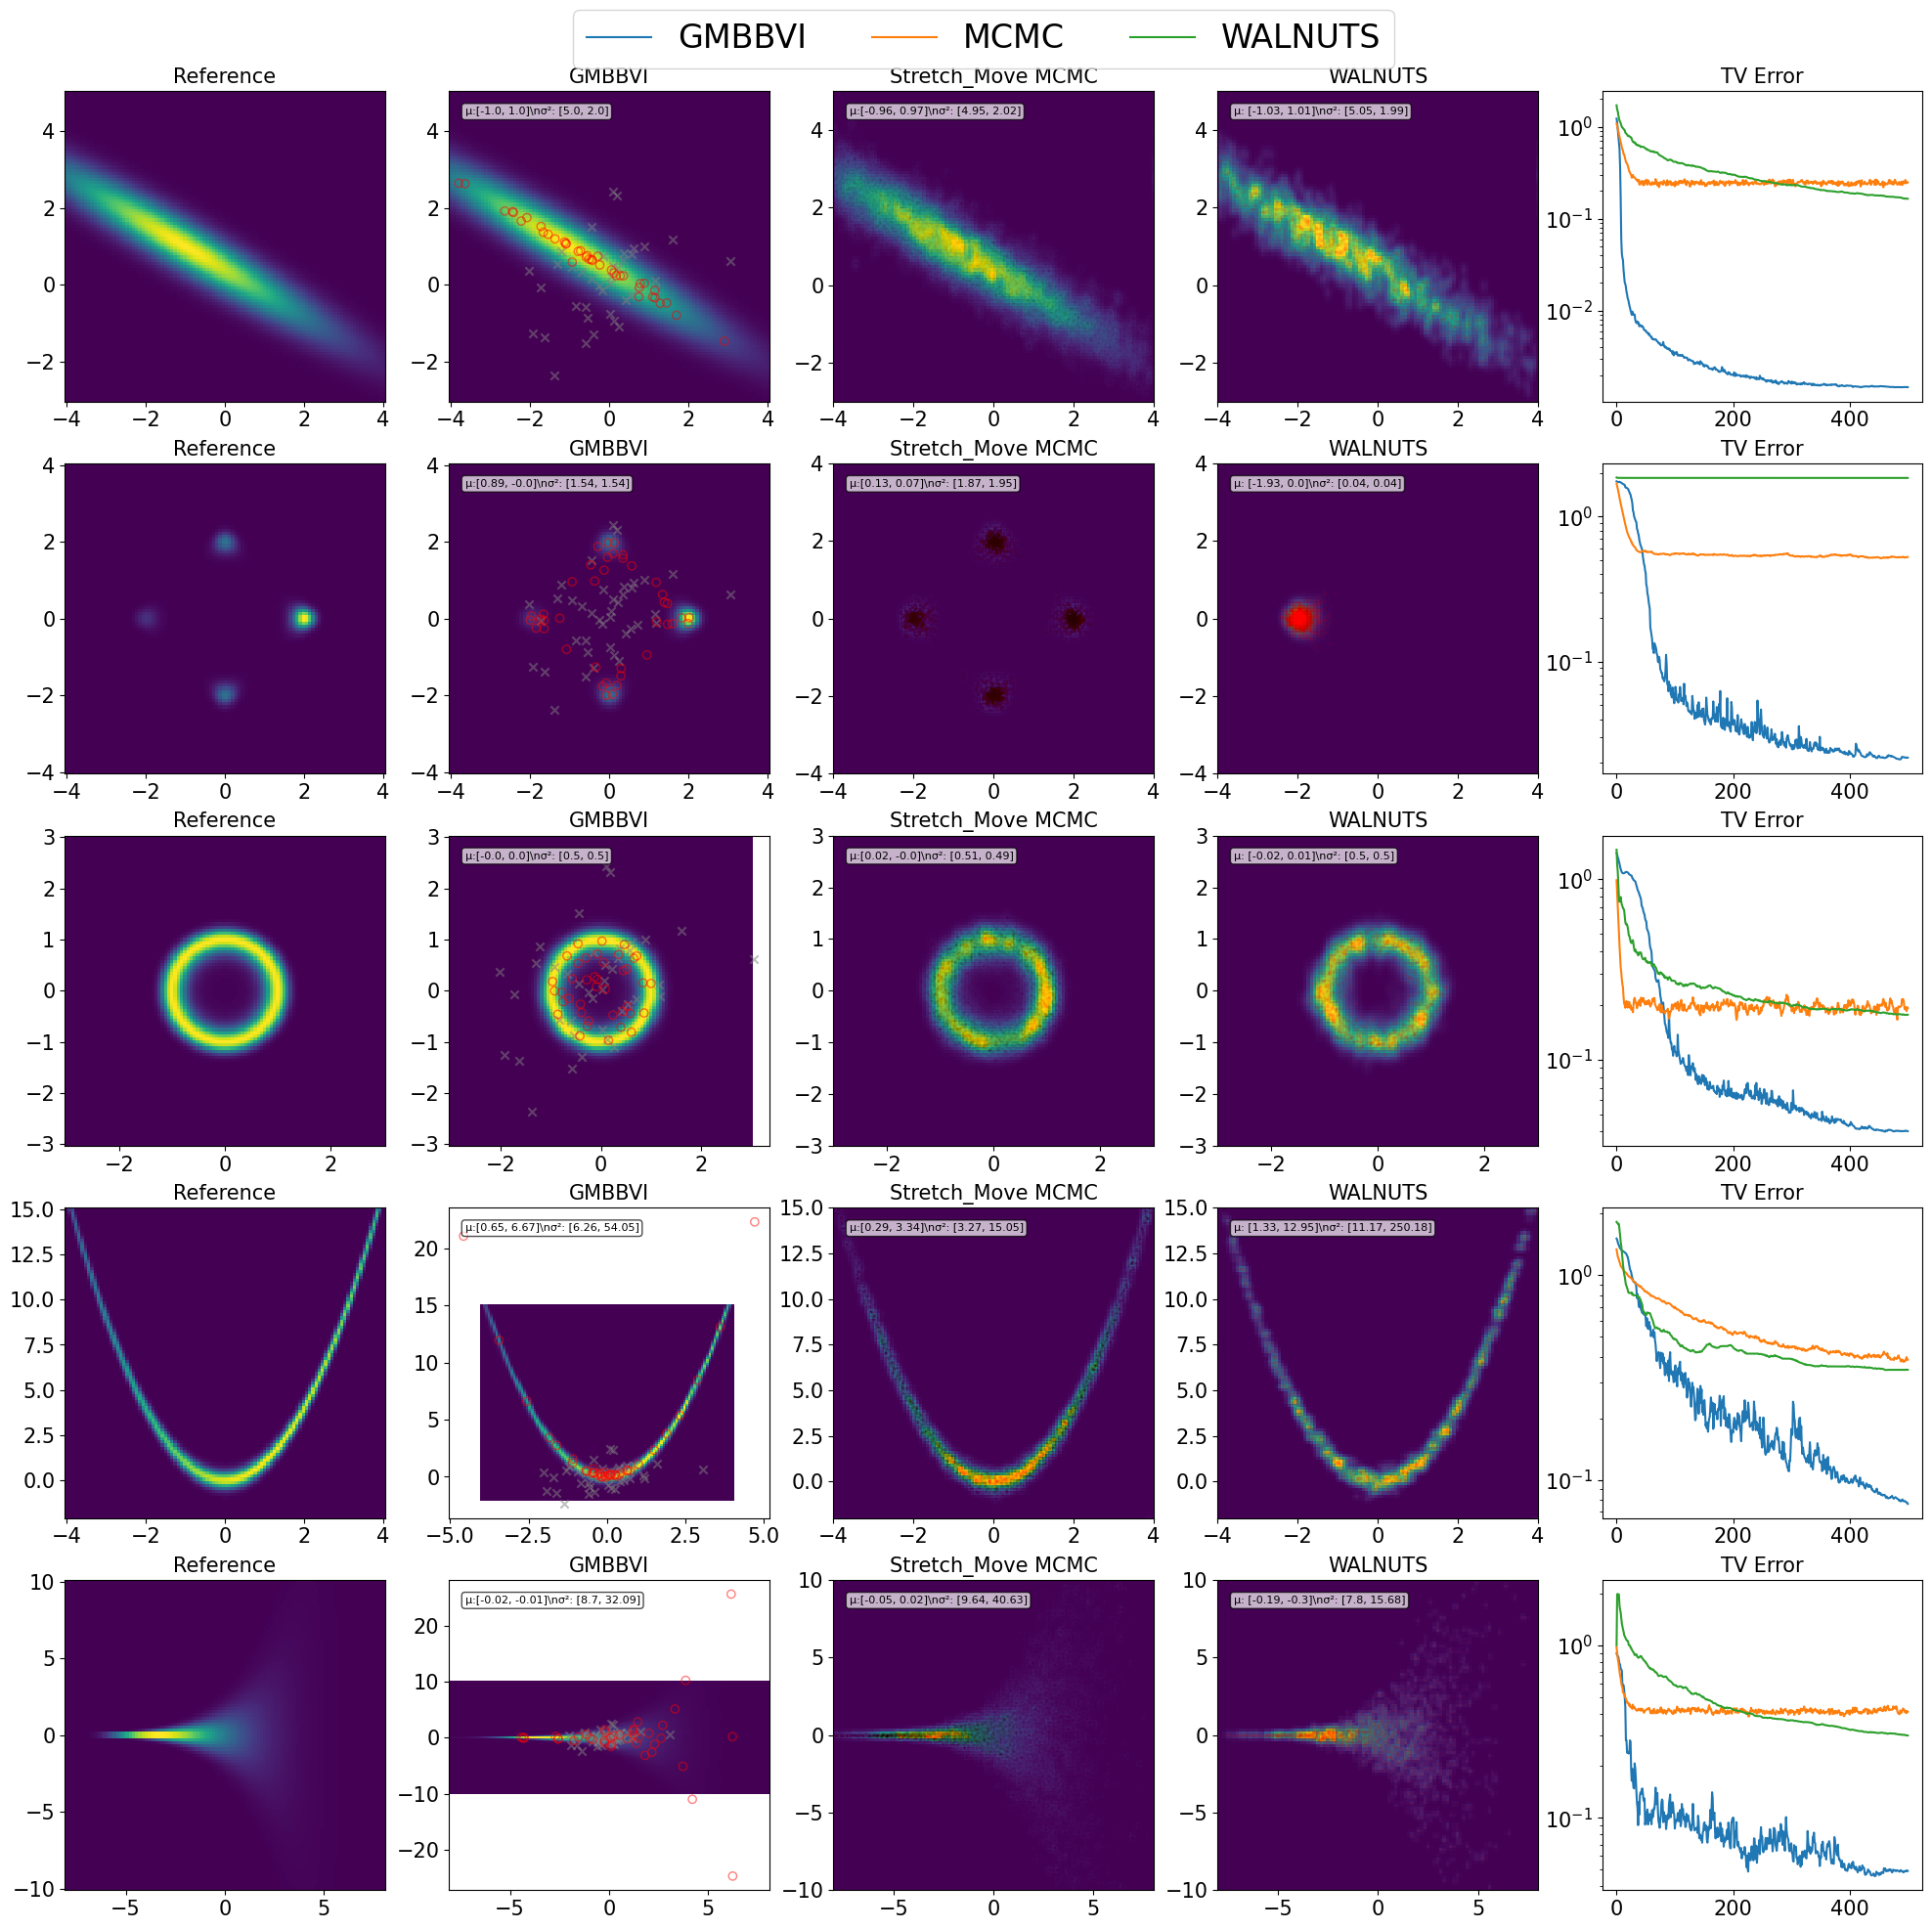

In [4]:
Random.seed!(111);
Nx, Ny = 100, 100

N_modes = 40 
N_x = 2
N_bbvi_sample = 4*N_x
alpha = 1
N_ens = 2000
Num = 5000 * alpha

fig, ax = PyPlot.subplots(nrows=5, ncols=5, sharex=false, sharey=false, figsize=(20,20))

N_iter = 500 * alpha
dt = 0.9
quadrature_type = "random_sampling"

x0_w  = ones(N_modes)/N_modes
μ0, Σ0 = zeros(N_x), Matrix(I(N_x)) 
x0_mean, xx0_cov = zeros(N_modes, N_x), zeros(N_modes, N_x, N_x)
for im = 1:N_modes
    x0_mean[im, :]    .= rand(MvNormal(zeros(N_x), Σ0)) + μ0
    xx0_cov[im, :, :] .= Σ0
end

q0 = randn(N_x)
ens_0=zeros(N_x,N_ens)
for j = 1:N_ens
    ens_0[:,j]  = rand(MvNormal(zeros(N_x), Σ0)) + μ0
end

@info "Running: Gaussian"
Gtype = "Gaussian"
ση = [1.0; 1.0; ones(N_x-2)]
y = [0.0; 1.0; zeros(N_x-2)]
arg = [1.0 1.0; 1.0 2.0]
args = (y, ση, arg, Gtype)
func_Phi(x) = Phi(x, args)
func_prob(x) = exp(-Phi(x, args))
func_Phi_marginal(x) = Phi(x, (y[1:2], ση[1:2], arg, Gtype))

t_gmbbvi = @elapsed obj_GMBBVI = Gaussian_mixture_GMBBVI(func_Phi, x0_w, x0_mean, xx0_cov; N_iter=N_iter, dt=dt, N_ens=N_bbvi_sample)
t_mcmc = @elapsed obj_MCMC = run_emcee_python(func_Phi, ens_0, N_iter)
t_walnuts = @elapsed obj_WALNUTS = run_walnuts_python(func_Phi, q0, N_x, Num)

@info "Gaussian - Time: GMBBVI: $(t_gmbbvi)s, MCMC: $(t_mcmc)s, WALNUTS: $(t_walnuts)s"
visualization(ax[1,:], obj_GMBBVI, obj_MCMC, obj_WALNUTS;
                          Nx=Nx, Ny=Ny, x_lim=[-4.0, 4.0], y_lim=[-3.0, 5.0], func_Phi=func_Phi_marginal, 
                          bandwidth=(0.06,0.11), make_label=false, N_iter=N_iter, Num = Num)

@info "Running: Four mode"
Gtype = "Four_modes"
ση = 1.0
y = [4.2297; 4.2297; 0.5; 0.0; zeros(N_x-2)]
args = (y, ση, 0, Gtype)
func_Phi(x)= Phi(x, args)
func_prob(x)=exp(-Phi(x, args))
func_Phi_marginal(x) = Phi(x, (y[1:4], ση, 0, Gtype))

t_gmbbvi = @elapsed obj_GMBBVI = Gaussian_mixture_GMBBVI(func_Phi, x0_w, x0_mean, xx0_cov; N_iter=N_iter, dt=dt, N_ens=N_bbvi_sample)
t_mcmc = @elapsed obj_MCMC = run_emcee_python(func_Phi, ens_0, N_iter)
t_walnuts = @elapsed obj_WALNUTS = run_walnuts_python(func_Phi, q0, N_x, Num)


@info "Four_modes - Time: GMBBVI: $(t_gmbbvi)s, MCMC: $(t_mcmc)s, WALNUTS: $(t_walnuts)s"
visualization(ax[2,:], obj_GMBBVI, obj_MCMC, obj_WALNUTS;
                          Nx=Nx, Ny=Ny, x_lim=[-4.0, 4.0], y_lim=[-4.0, 4.0], func_Phi=func_Phi_marginal, 
                          bandwidth=(0.06,0.11), make_label=false, N_iter=N_iter, Num = Num)


@info "Running: Circle"
Gtype = "Circle"
ση = [0.3; ones(N_x-2)]
y = [1.0; zeros(N_x-2)]
arg = Matrix(I, 2, 2)
args = (y, ση, arg, Gtype)
func_Phi(x) = Phi(x, args)
func_prob(x) = exp(-Phi(x, args))
func_Phi_marginal(x) = Phi(x, (y[1:1], ση[1:1], arg, Gtype))

t_gmbbvi = @elapsed obj_GMBBVI = Gaussian_mixture_GMBBVI(func_Phi, x0_w, x0_mean, xx0_cov; N_iter=N_iter, dt=dt, N_ens=N_bbvi_sample)
t_mcmc = @elapsed obj_MCMC = run_emcee_python(func_Phi, ens_0, N_iter)
t_walnuts = @elapsed obj_WALNUTS = run_walnuts_python(func_Phi, q0, N_x, Num)

@info "Circle - Time: GMBBVI: $(t_gmbbvi)s, MCMC: $(t_mcmc)s, WALNUTS: $(t_walnuts)s"
visualization(ax[3,:], obj_GMBBVI, obj_MCMC, obj_WALNUTS;
                          Nx=Nx, Ny=Ny, x_lim=[-3.0, 3.0], y_lim=[-3.0, 3.0], func_Phi=func_Phi_marginal, 
                          bandwidth=(0.06,0.11), make_label=false, N_iter=N_iter, Num = Num)

@info "Running: Banana"
Gtype = "Banana"
ση = [sqrt(10.0); sqrt(10.0); ones(N_x-2)]
y = [0.0; 1.0; zeros(N_x-2)]
arg = 10.0
args = (y, ση, arg, Gtype)
func_Phi(x) = Phi(x, args)
func_prob(x) = exp(-Phi(x, args))
func_Phi_marginal(x) = Phi(x, (y[1:2], ση[1:2], arg, Gtype))

t_gmbbvi = @elapsed obj_GMBBVI = Gaussian_mixture_GMBBVI(func_Phi, x0_w, x0_mean, xx0_cov; N_iter=N_iter, dt=dt, N_ens=N_bbvi_sample)
t_mcmc = @elapsed obj_MCMC = run_emcee_python(func_Phi, ens_0, N_iter)
t_walnuts = @elapsed obj_WALNUTS = run_walnuts_python(func_Phi, q0, N_x, Num)

@info "Banana - Time: GMBBVI: $(t_gmbbvi)s, MCMC: $(t_mcmc)s, WALNUTS: $(t_walnuts)s"
visualization(ax[4,:], obj_GMBBVI, obj_MCMC, obj_WALNUTS;
                          Nx=Nx, Ny=Ny, x_lim=[-4.0, 4.0], y_lim=[-2.0, 15.0], func_Phi=func_Phi_marginal, 
                          bandwidth=(0.06,0.11), make_label=false, N_iter=N_iter, Num = Num)

@info "Running: Funnel"
Gtype = "Funnel"
ση = ones(N_x)
y = zeros(N_x)
arg = Matrix(I, N_x-1, N_x-1)
args = (y, ση, arg, Gtype)
func_Phi(x) = Phi(x, args)
func_prob(x) = exp(-Phi(x, args))
func_Phi_marginal(x) = Phi(x, (y[1:2], ση[1:2], Matrix(I, 1, 1), Gtype))

t_gmbbvi = @elapsed obj_GMBBVI = Gaussian_mixture_GMBBVI(func_Phi, x0_w, x0_mean, xx0_cov; N_iter=N_iter, dt=dt, N_ens=N_bbvi_sample)
t_mcmc = @elapsed obj_MCMC = run_emcee_python(func_Phi, ens_0, N_iter)
t_walnuts = @elapsed obj_WALNUTS = run_walnuts_python(func_Phi, q0, N_x, Num)

@info "Funnel - Time: GMBBVI: $(t_gmbbvi)s, MCMC: $(t_mcmc)s, WALNUTS: $(t_walnuts)s"
visualization(ax[5,:], obj_GMBBVI, obj_MCMC, obj_WALNUTS;
                          Nx=Nx, Ny=Ny, x_lim=[-8.0, 8.0], y_lim=[-10.0, 10.0], func_Phi=func_Phi_marginal, 
                          bandwidth=(0.06,0.11), make_label=false, N_iter=N_iter, Num = Num)

for r in 1:5
    ax[r,1].set_title("Reference", fontsize=15)
    ax[r,2].set_title("GMBBVI", fontsize=15)
    ax[r,3].set_title("Stretch_Move MCMC", fontsize=15)
    ax[r,4].set_title("WALNUTS", fontsize=15)
    ax[r,5].set_title("TV Error", fontsize=15)
end

handles, labels = ax[end, end].get_legend_handles_labels()
fig.legend(handles,labels,loc = "upper center",bbox_to_anchor=(0.5,1.0),ncol=3,fontsize=24)
fig.subplots_adjust(bottom=0.03,top=0.95,left=0.03,right=0.98,hspace=0.2)

fig.savefig("Benchmark_$(N_x)_$(N_iter).pdf")